In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import os 
import xarray as xr
import numpy as np
import pandas as pd
import cftime

#### Load Roemmich and Gilson Argo 2004-2018 datasets

In [2]:
os.chdir('/backup/tuq41374/observations/Roemmich_Gilson_2009')

salinity_04_18 = xr.open_dataset('RG_ArgoClim_Salinity_2019.nc',
                          decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
temperature_04_18 = xr.open_dataset('RG_ArgoClim_Temperature_2019.nc',
                          decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})

#### Load Roemmich and Gilson Argo extension datasets

#### 2019-2024:

In [5]:
def load_RG_year(year):
    """
    Load and merge monthly RG Argo climatology files for a given year.

    Parameters
    ----------
    year : int
        Year to load (e.g., 2019)

    Returns
    -------
    xr.Dataset
        Merged dataset for the given year
    """
    months = [
        "01", "02", "03", "04", "05", "06",
        "07", "08", "09", "10", "11", "12"
    ]

    datasets = []

    for month in months:
        fname = f"RG_ArgoClim_{year}{month}_2019.nc"
        ds = xr.open_dataset(fname, decode_times=False).rename({
            "TIME": "time",
            "PRESSURE": "pressure",
            "LONGITUDE": "longitude",
            "LATITUDE": "latitude"
        })
        datasets.append(ds)

    return xr.merge(datasets)


RG_2019 = load_RG_year(2019)
RG_2020 = load_RG_year(2020)
RG_2021 = load_RG_year(2021)
RG_2022 = load_RG_year(2022)
RG_2023 = load_RG_year(2023)
RG_2024 = load_RG_year(2024)

In [6]:
# check that it worked 

RG_2020

<xarray.Dataset>
Dimensions:                   (longitude: 360, latitude: 145, pressure: 58,
                               time: 12)
Coordinates:
  * longitude                 (longitude) float32 20.5 21.5 22.5 ... 378.5 379.5
  * latitude                  (latitude) float32 -64.5 -63.5 -62.5 ... 78.5 79.5
  * pressure                  (pressure) float32 2.5 10.0 ... 1.9e+03 1.975e+03
  * time                      (time) float32 192.5 193.5 194.5 ... 202.5 203.5
Data variables:
    ARGO_TEMPERATURE_ANOMALY  (time, pressure, latitude, longitude) float32 1...
    ARGO_SALINITY_ANOMALY     (time, pressure, latitude, longitude) float32 -...

#### 2025 (no December)

In [7]:
RG_2025_JAN = xr.open_dataset('RG_ArgoClim_202501_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_FEB = xr.open_dataset('RG_ArgoClim_202502_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_MAR = xr.open_dataset('RG_ArgoClim_202503_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_APR = xr.open_dataset('RG_ArgoClim_202504_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_MAY = xr.open_dataset('RG_ArgoClim_202505_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_JUN = xr.open_dataset('RG_ArgoClim_202506_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_JUL = xr.open_dataset('RG_ArgoClim_202507_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_AUG = xr.open_dataset('RG_ArgoClim_202508_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_SEP = xr.open_dataset('RG_ArgoClim_202509_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_OCT = xr.open_dataset('RG_ArgoClim_202510_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_NOV = xr.open_dataset('RG_ArgoClim_202511_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})
RG_2025_DEC = xr.open_dataset('RG_ArgoClim_202512_2019.nc',
                         decode_times=False).rename({'TIME':'time',
                                                      'PRESSURE':'pressure',
                                                      'LONGITUDE':'longitude',
                                                      'LATITUDE':'latitude'})


### merge along the time-dimension
RG_2025 = xr.merge([RG_2025_JAN,
                   RG_2025_FEB,
                   RG_2025_MAR,
                   RG_2025_APR,
                   RG_2025_MAY,
                   RG_2025_JUN,
                   RG_2025_JUL,
                   RG_2025_AUG,
                   RG_2025_SEP,
                   RG_2025_OCT,
                   RG_2025_NOV,
                   RG_2025_DEC])

#### Merge climatology 2004 to 2018 datasets and extensions for T and S:

In [8]:
RG_Temperature_04_25 = xr.merge([temperature_04_18,
                           RG_2019.ARGO_TEMPERATURE_ANOMALY,
                           RG_2020.ARGO_TEMPERATURE_ANOMALY,
                           RG_2021.ARGO_TEMPERATURE_ANOMALY,
                           RG_2022.ARGO_TEMPERATURE_ANOMALY,
                           RG_2023.ARGO_TEMPERATURE_ANOMALY,
                           RG_2024.ARGO_TEMPERATURE_ANOMALY,
                           RG_2025.ARGO_TEMPERATURE_ANOMALY])

In [9]:
RG_Salinity_04_25 = xr.merge([salinity_04_18,
                           RG_2019.ARGO_SALINITY_ANOMALY,
                           RG_2020.ARGO_SALINITY_ANOMALY,
                           RG_2021.ARGO_SALINITY_ANOMALY,
                           RG_2022.ARGO_SALINITY_ANOMALY,
                           RG_2023.ARGO_SALINITY_ANOMALY,
                           RG_2024.ARGO_SALINITY_ANOMALY,
                           RG_2025.ARGO_SALINITY_ANOMALY]) 

In [10]:
RG_2025

<xarray.Dataset>
Dimensions:                   (longitude: 360, latitude: 145, pressure: 58,
                               time: 12)
Coordinates:
  * longitude                 (longitude) float32 20.5 21.5 22.5 ... 378.5 379.5
  * latitude                  (latitude) float32 -64.5 -63.5 -62.5 ... 78.5 79.5
  * pressure                  (pressure) float32 2.5 10.0 ... 1.9e+03 1.975e+03
  * time                      (time) float32 252.5 253.5 254.5 ... 262.5 263.5
Data variables:
    ARGO_TEMPERATURE_ANOMALY  (time, pressure, latitude, longitude) float32 2...
    ARGO_SALINITY_ANOMALY     (time, pressure, latitude, longitude) float32 -...

In [13]:
# Check to make sure length is 264

len(RG_Temperature_04_25.time)

264

### Create time axis to from Jan-01-2004 to Dec-01-2025 and assign this time axis to the datasets

In [22]:
time_Jan_04_Dec_25 = pd.date_range(start="2004-01-01",
                     freq="M",
                     periods=len(RG_Temperature_04_25.time))

In [24]:
RG_Temperature_04_25 = RG_Temperature_04_25.drop(labels="time").assign_coords({'time':time_Jan_04_Dec_25})
RG_Salinity_04_25 = RG_Salinity_04_25.drop(labels="time").assign_coords({'time':time_Jan_04_Dec_25})

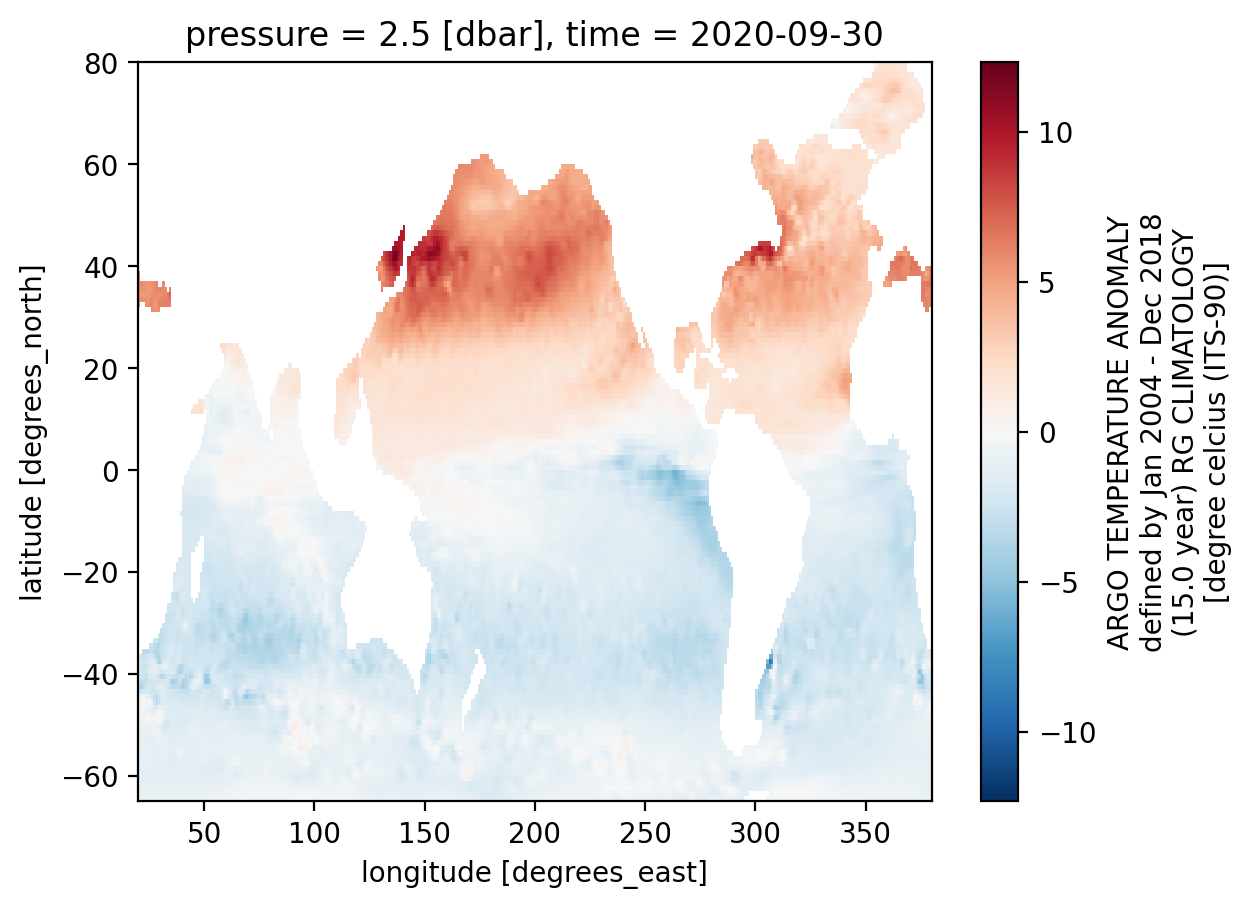

In [26]:
RG_Temperature_04_25.ARGO_TEMPERATURE_ANOMALY.isel(time=200,pressure=0).plot()

### Save out as netcdf files:

In [27]:
os.chdir('/home/tu.temple.edu/tuk08919/BAMS_2025')
RG_Temperature_04_25.to_netcdf('Roemmich_Gilson_Temperature_Jan2004_Dec2025.nc')
RG_Salinity_04_25.to_netcdf('Roemmich_Gilson_Salinity_Jan2004_Dec2025.nc')

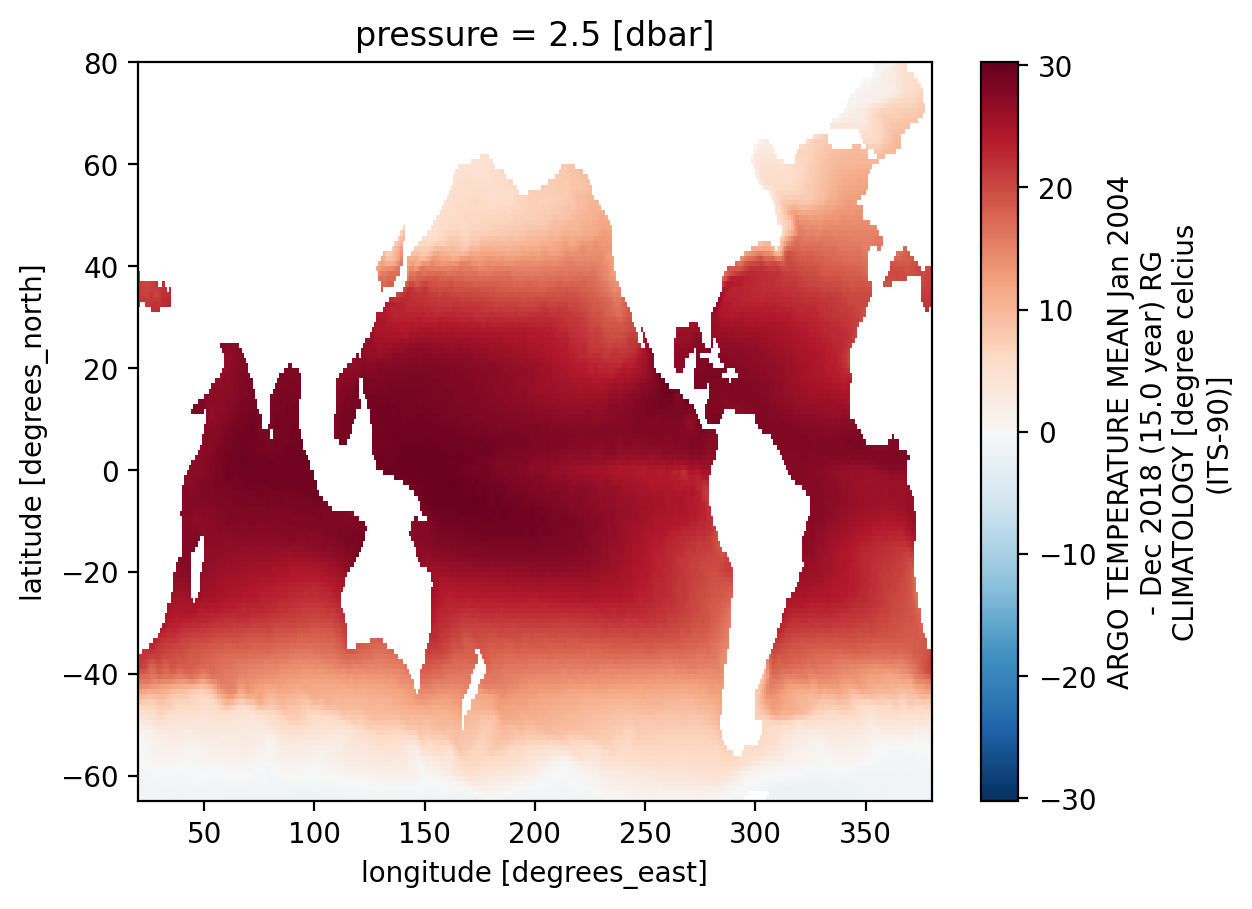

In [28]:
temperature_04_18.ARGO_TEMPERATURE_MEAN.isel(pressure=0).plot()

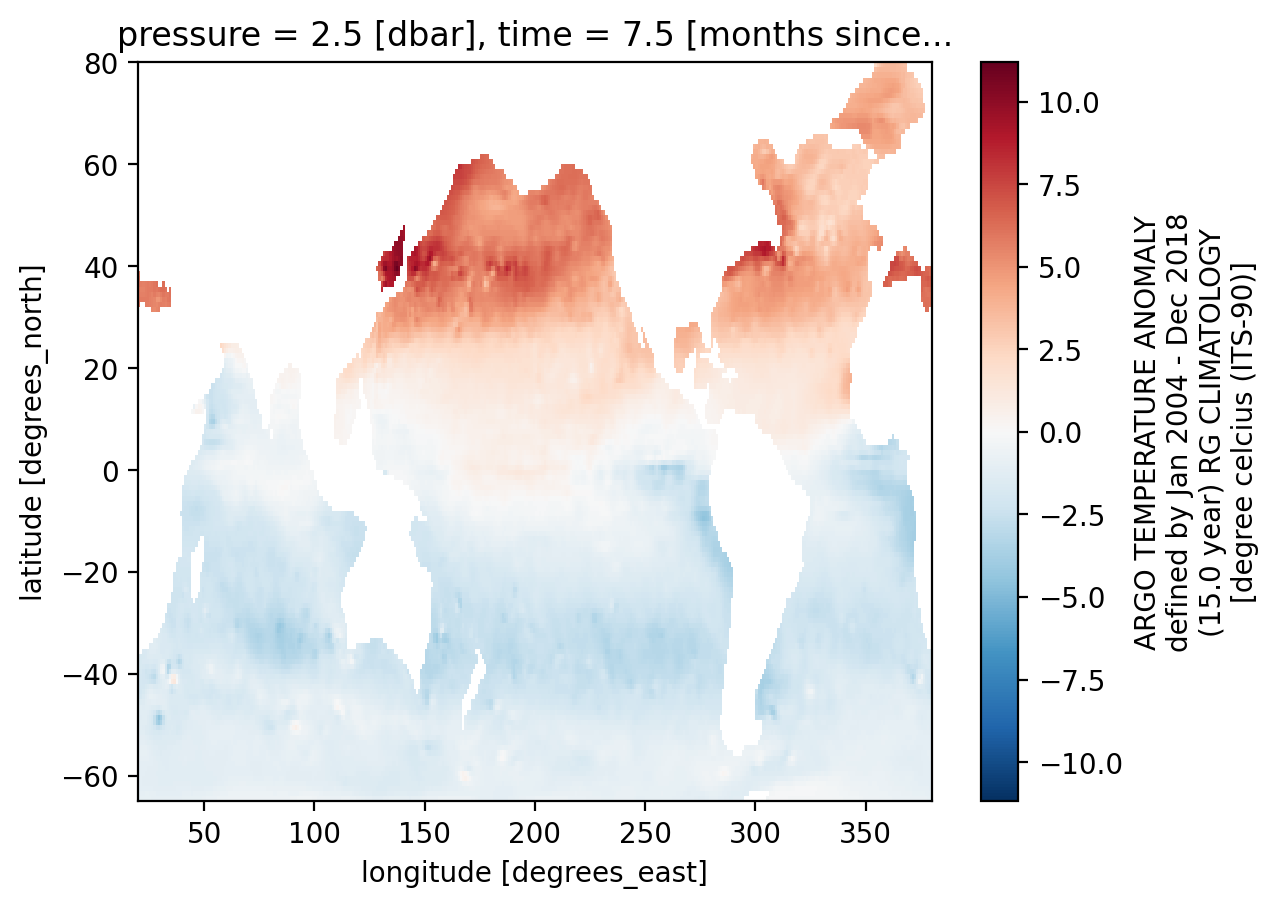

In [29]:
temperature_04_18.ARGO_TEMPERATURE_ANOMALY.isel(pressure=0,time=7).plot()